In [1]:
import pandas as pd
import numpy as np  
import xgboost as xgb
import optuna
from optuna_integration import XGBoostPruningCallback
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import shap
from dotenv import load_dotenv
import os

# Establish Country & Pollutant

In [2]:
load_dotenv()

True

In [3]:
COUNTRY_CODE = os.getenv("COUNTRY_CODE")   
POLLUTANT = "O3"

In [4]:
base_path = os.getenv("BASE_DATA_PATH")
file_name = f"{COUNTRY_CODE}_{POLLUTANT}_Daily_Cleaned.parquet"
file_path = os.path.join(base_path, file_name)

In [5]:
df = pd.read_parquet(file_path, engine = 'pyarrow')

In [6]:
df.head(10)

,Samplingpoint,Start,Value
0,IE/SPO.IE.IE0001RSample1_7,2013-01-01,92.855797
1,IE/SPO.IE.IE0001RSample1_7,2013-01-02,76.622222
2,IE/SPO.IE.IE0001RSample1_7,2013-01-03,73.370833
3,IE/SPO.IE.IE0001RSample1_7,2013-01-04,77.793750
4,IE/SPO.IE.IE0001RSample1_7,2013-01-05,78.381250
5,IE/SPO.IE.IE0001RSample1_7,2013-01-06,81.093750
6,IE/SPO.IE.IE0001RSample1_7,2013-01-07,83.491667
7,IE/SPO.IE.IE0001RSample1_7,2013-01-08,67.029167
8,IE/SPO.IE.IE0001RSample1_7,2013-01-09,60.150000
9,IE/SPO.IE.IE0001RSample1_7,2013-01-10,79.222917


# Machine Learning Preperation - Feature Extraction & Dropping NaN

In [7]:
df['Start'] = pd.to_datetime(df['Start']) 
df = df.sort_values(by=['Samplingpoint', 'Start']).reset_index(drop=True) # sorting by station and start(date) and resetting index

df['Samplingpoint'] = df['Samplingpoint'].astype('category') # set as a category to use as category feature (can avpid using pd.getdummies onehotencoding and creating more columns), faster processing and less memory usage

In [8]:
# Extracting time based features
df['DayOfWeek'] = df['Start'].dt.dayofweek
df['Month'] = df['Start'].dt.month
df['DayOfYear'] = df['Start'].dt.dayofyear
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

In [9]:
df['Lag_1'] = df.groupby('Samplingpoint')['Value'].shift(1) 
df['Lag_7'] = df.groupby('Samplingpoint')['Value'].shift(7) 

In [10]:
df = df.set_index('Start') # Need index to be the 'Start'(date) column for rolling with time-based windows to work properly

df['Rolling_Mean_7D'] = df.groupby('Samplingpoint')['Value'].transform(
    lambda x: x.rolling('7D', min_periods=4).mean() # 7d creates rolling window of 7 calendar days instead of last 7 rows
)
df = df.reset_index()

In [11]:
df['Target'] = df.groupby('Samplingpoint')['Value'].shift(-1) # Target (y), shfts value back by 1 on the indexlevel, to get the next day today

In [12]:
print(f"Data shape after Feature Engineering {df.shape}")
df.head(10)

Data shape after Feature Engineering (69014, 11)


,Start,Samplingpoint,Value,DayOfWeek,Month,DayOfYear,IsWeekend,Lag_1,Lag_7,Rolling_Mean_7D,Target
0,2013-01-01,IE/SPO.IE.IE0001RSample1_7,92.855797,1,1,1,0,NaN,NaN,NaN,76.622222
1,2013-01-02,IE/SPO.IE.IE0001RSample1_7,76.622222,2,1,2,0,92.855797,NaN,NaN,73.370833
2,2013-01-03,IE/SPO.IE.IE0001RSample1_7,73.370833,3,1,3,0,76.622222,NaN,NaN,77.793750
3,2013-01-04,IE/SPO.IE.IE0001RSample1_7,77.793750,4,1,4,0,73.370833,NaN,80.160651,78.381250
4,2013-01-05,IE/SPO.IE.IE0001RSample1_7,78.381250,5,1,5,1,77.793750,NaN,79.804771,81.093750
5,2013-01-06,IE/SPO.IE.IE0001RSample1_7,81.093750,6,1,6,1,78.381250,NaN,80.019600,83.491667
6,2013-01-07,IE/SPO.IE.IE0001RSample1_7,83.491667,0,1,7,0,81.093750,NaN,80.515610,67.029167
7,2013-01-08,IE/SPO.IE.IE0001RSample1_7,67.029167,1,1,8,0,83.491667,92.855797,76.826091,60.150000
8,2013-01-09,IE/SPO.IE.IE0001RSample1_7,60.150000,2,1,9,0,67.029167,76.622222,74.472917,79.222917
9,2013-01-10,IE/SPO.IE.IE0001RSample1_7,79.222917,3,1,10,0,60.150000,73.370833,75.308929,77.512500


In [13]:
df_ml_ready = df.dropna(subset=['Target']).reset_index(drop=True) # drop Nan target but keep the featues with xgboost
display(df_ml_ready.head(10))
df_ml_ready.isna().sum()

,Start,Samplingpoint,Value,DayOfWeek,Month,DayOfYear,IsWeekend,Lag_1,Lag_7,Rolling_Mean_7D,Target
0,2013-01-01,IE/SPO.IE.IE0001RSample1_7,92.855797,1,1,1,0,NaN,NaN,NaN,76.622222
1,2013-01-02,IE/SPO.IE.IE0001RSample1_7,76.622222,2,1,2,0,92.855797,NaN,NaN,73.370833
2,2013-01-03,IE/SPO.IE.IE0001RSample1_7,73.370833,3,1,3,0,76.622222,NaN,NaN,77.793750
3,2013-01-04,IE/SPO.IE.IE0001RSample1_7,77.793750,4,1,4,0,73.370833,NaN,80.160651,78.381250
4,2013-01-05,IE/SPO.IE.IE0001RSample1_7,78.381250,5,1,5,1,77.793750,NaN,79.804771,81.093750
5,2013-01-06,IE/SPO.IE.IE0001RSample1_7,81.093750,6,1,6,1,78.381250,NaN,80.019600,83.491667
6,2013-01-07,IE/SPO.IE.IE0001RSample1_7,83.491667,0,1,7,0,81.093750,NaN,80.515610,67.029167
7,2013-01-08,IE/SPO.IE.IE0001RSample1_7,67.029167,1,1,8,0,83.491667,92.855797,76.826091,60.150000
8,2013-01-09,IE/SPO.IE.IE0001RSample1_7,60.150000,2,1,9,0,67.029167,76.622222,74.472917,79.222917
9,2013-01-10,IE/SPO.IE.IE0001RSample1_7,79.222917,3,1,10,0,60.150000,73.370833,75.308929,77.512500


Start                 0
Samplingpoint         0
Value               253
DayOfWeek             0
Month                 0
DayOfYear             0
IsWeekend             0
Lag_1               476
Lag_7              1361
Rolling_Mean_7D     696
Target                0
dtype: int64

# Machine Learning

In [14]:
features = ['Samplingpoint', 'Value', 'DayOfWeek', 'Month', 'DayOfYear', 'IsWeekend', 'Lag_1', 'Lag_7', 'Rolling_Mean_7D']

In [15]:
train_data = df_ml_ready[(df_ml_ready['Start'] >= '2013-01-01') & (df_ml_ready['Start'] <= '2020-12-31')]
val_data = df_ml_ready[(df_ml_ready['Start'] >= '2021-01-01') & (df_ml_ready['Start'] <= '2022-12-31')]
test_data = df_ml_ready[(df_ml_ready['Start'] >= '2023-01-01') & (df_ml_ready['Start'] <= '2024-12-31')]

# Sort purely by date so TimeSeriesSplit moves properly through time, no longer need to sort by station anymore
train_data = train_data.sort_values(by='Start').reset_index(drop=True)
val_data = val_data.sort_values(by='Start').reset_index(drop=True)
test_data = test_data.sort_values(by='Start').reset_index(drop=True)

X_train, y_train = train_data[features], train_data['Target']
X_val, y_val = val_data[features], val_data['Target']
X_test, y_test = test_data[features], test_data['Target']

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (35575, 9), Val shape: (12417, 9), Test shape: (13480, 9)


In [16]:
def objective(trial):
    # Hyperparameeter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist', # faster for cpu 
        # 'tree_method' : 'exact', # more accurate but slower
        'n_estimators': trial.suggest_int('n_estimators', 100, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # prevent overfitting
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True)  
    }
    
    tscv = TimeSeriesSplit(n_splits=5) # Time Series Cross Validation Split (5 splits/folds)
    cv_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]


        model = xgb.XGBRegressor(
            **params, 
            enable_categorical=True, # for the samplingpoint categorical
            early_stopping_rounds=30,
            random_state=42 # for reproducatbility
        )
        
        model.fit(
            X_fold_train, y_fold_train, 
            eval_set=[(X_fold_val, y_fold_val)],  # validation data for early stopping
            verbose=False, 
        )

        preds = model.predict(X_fold_val)
        rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
        cv_scores.append(rmse)

        # Report the RMSE for this fold to Optuna for pruning decisions
        trial.report(rmse, step=fold_idx)

        # Handle pruning based on the fold's performance
        if trial.should_prune():
            raise optuna.TrialPruned()
        

    weights = np.arange(1, len(cv_scores) + 1) # more recent folds get higher weight, as there will be more data to train on and gives better representation of recenncy
    return np.average(cv_scores, weights=weights)


In [17]:
# Bayesian Hyperparameter Optimisation using Optuna
study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)) # minimise rmse and use median pruner to stop bad trials early based on median of intermediate results
study.optimize(objective, n_trials=200) 
print(f"Best trial parameters: {study.best_params}")

[I 2026-03-12 02:18:10,665] A new study created in memory with name: no-name-59c3b387-b3b4-40f3-bb36-97eaaedf8605
[I 2026-03-12 02:18:24,441] Trial 0 finished with value: 11.22206322573346 and parameters: {'n_estimators': 1046, 'learning_rate': 0.011229193935044946, 'max_depth': 8, 'subsample': 0.8447347580431454, 'colsample_bytree': 0.777214407010286, 'min_child_weight': 9, 'gamma': 0.11393595232395415, 'reg_lambda': 0.0016449441335184972}. Best is trial 0 with value: 11.22206322573346.
[I 2026-03-12 02:18:27,508] Trial 1 finished with value: 11.148134820731952 and parameters: {'n_estimators': 1083, 'learning_rate': 0.0744122689003618, 'max_depth': 6, 'subsample': 0.8351474790119496, 'colsample_bytree': 0.6040405299084726, 'min_child_weight': 10, 'gamma': 0.41452924311624895, 'reg_lambda': 0.04293706782238954}. Best is trial 1 with value: 11.148134820731952.
[I 2026-03-12 02:18:31,607] Trial 2 finished with value: 11.01869931226535 and parameters: {'n_estimators': 1089, 'learning_rate

Best trial parameters: {'n_estimators': 303, 'learning_rate': 0.04050696390389426, 'max_depth': 3, 'subsample': 0.982318124822779, 'colsample_bytree': 0.9880480243998606, 'min_child_weight': 7, 'gamma': 4.357190888070293, 'reg_lambda': 0.05253010908344112}


In [18]:
# Incorporation the validating set into train set after opitmal hyperparameters found

# Use X_val purely to find the optimal stopping point
temp_model = xgb.XGBRegressor(
    **study.best_params,
    objective='reg:squarederror', 
    enable_categorical=True,
    tree_method = 'hist', 
    early_stopping_rounds=30,
    random_state=42
    
)

temp_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Get the exact number of trees where it peaked
optimal_trees = temp_model.best_iteration + 1  # best_iteration is zero-indexed, so add 1 to get the actual number of trees

# Make a copy of the best parameters and overwrite with best trees so it works in the best (final) model
final_params = study.best_params.copy()
final_params['n_estimators'] = optimal_trees

X_train_full = pd.concat([X_train, X_val]) # concat train and val sets to retrain final model on all data up to 2022m(recent trends)
y_train_full = pd.concat([y_train, y_val])


# Retrain with our final (best) hyperparams with new trian data
best_model = xgb.XGBRegressor(
    **final_params,
    objective='reg:squarederror',
    tree_method='hist', 
    enable_categorical=True,
    random_state=42
)


best_model.fit(X_train_full, y_train_full, verbose=100)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9880480243998606
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [19]:
# Predit on the Test Set
test_preds = best_model.predict(X_test)

# Results & Evaluation

In [20]:
# Evaluate Model
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
mae = mean_absolute_error(y_test, test_preds)
r2 = r2_score(y_test, test_preds)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

RMSE: 10.4276
MAE:  8.0366
R2:   0.6285


In [21]:
# For Comparrison a naive non ML just guessing that tomorrow's O3 will be the same as today
naive_preds = X_test['Value'].dropna()

# if you want the RMSE you must compare against the same rows of y_test
naive_rmse = np.sqrt(
    mean_squared_error(y_test.loc[naive_preds.index], naive_preds)
)

print(f"XGBoost RMSE: {rmse:.4f}")
print(f"Naive Baseline RMSE: {naive_rmse:.4f}")

XGBoost RMSE: 10.4276
Naive Baseline RMSE: 11.6705


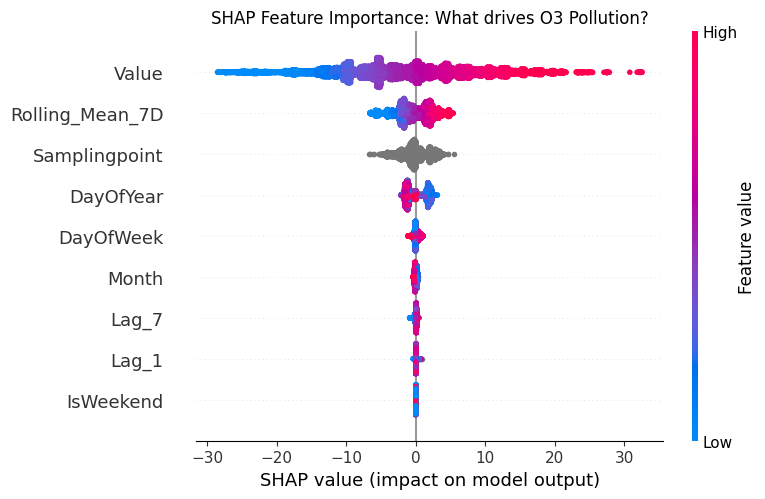

In [22]:
# Initialize the SHAP Explainer using your trained XGBoost model
explainer = shap.TreeExplainer(best_model) # For XGBoost use TreeExplaienr

shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("SHAP Feature Importance: What drives O3 Pollution?")
plt.tight_layout()
plt.show()

<BarContainer object of 8 artists>

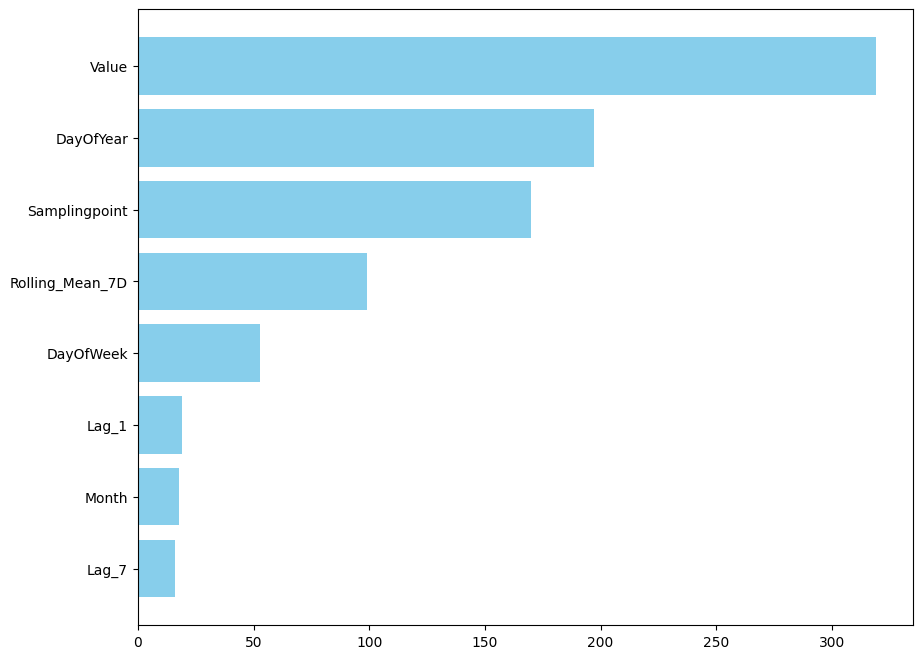

In [23]:
importance = best_model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)


top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)

RMSE: 10.4276
MAE:  8.0366
R2:   0.6285
Station IE/SPO.IE.IE0001RSample1_7 -> RMSE: 9.41 | MAE: 7.29 | R2: 0.50


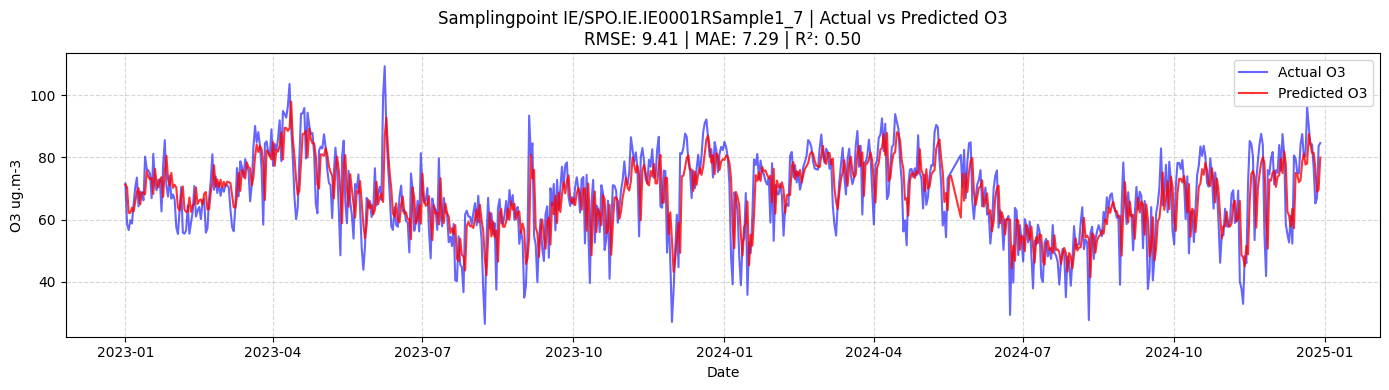

Station IE/SPO.IE.IE027DSample2_7 -> RMSE: 10.45 | MAE: 8.06 | R2: 0.53


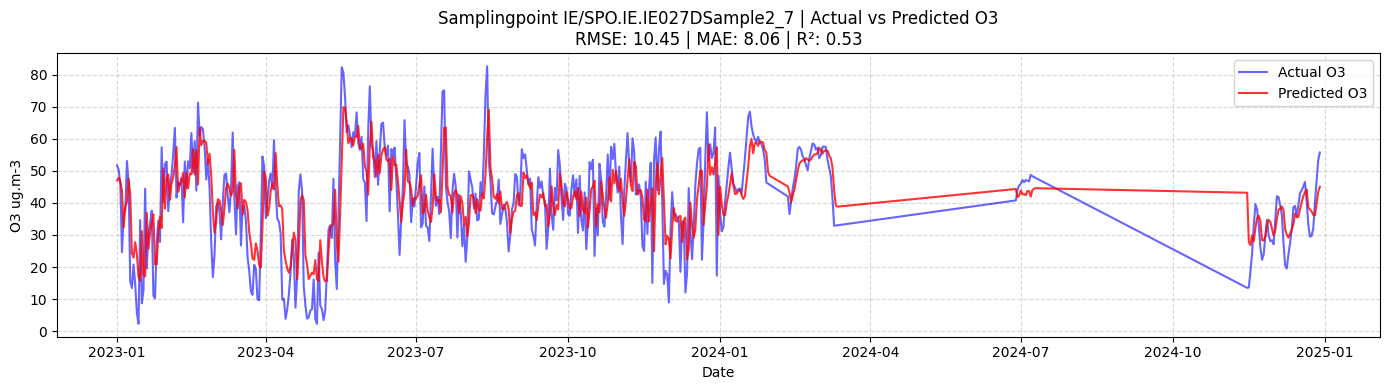

Station IE/SPO.IE.IE0028ASample1_7 -> RMSE: 11.20 | MAE: 8.77 | R2: 0.53


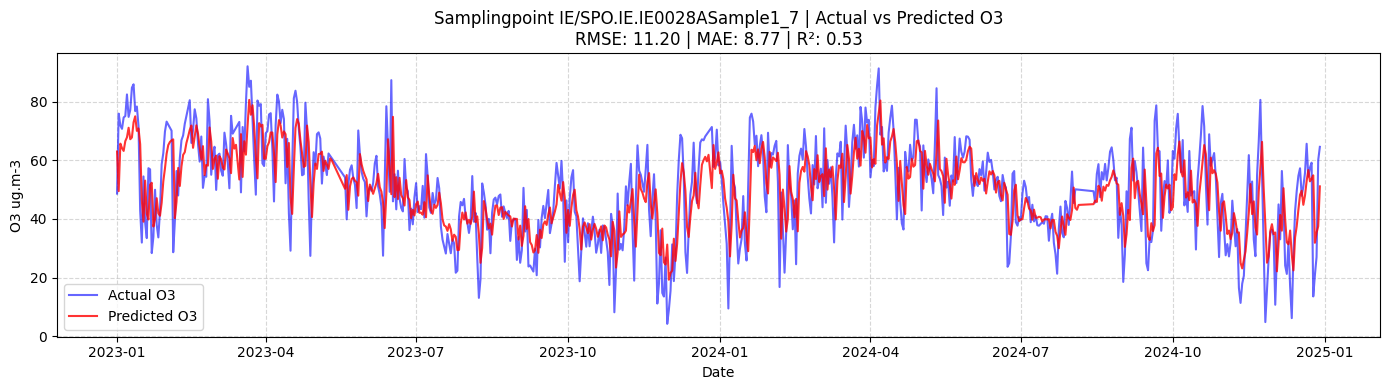

Station IE/SPO.IE.IE0031RSample1_7 -> RMSE: 8.55 | MAE: 6.80 | R2: 0.52


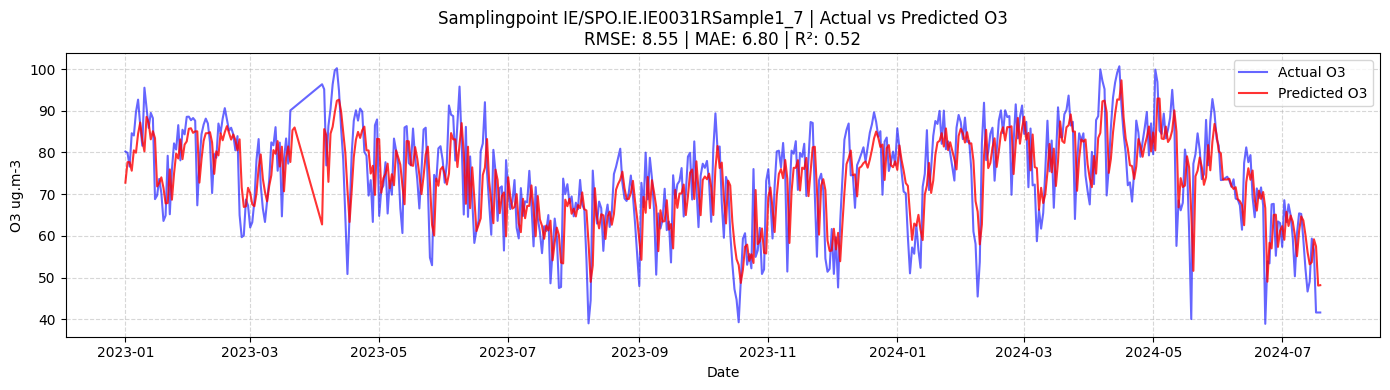

Station IE/SPO.IE.IE003DPSample1_7 -> RMSE: 9.35 | MAE: 7.23 | R2: 0.42


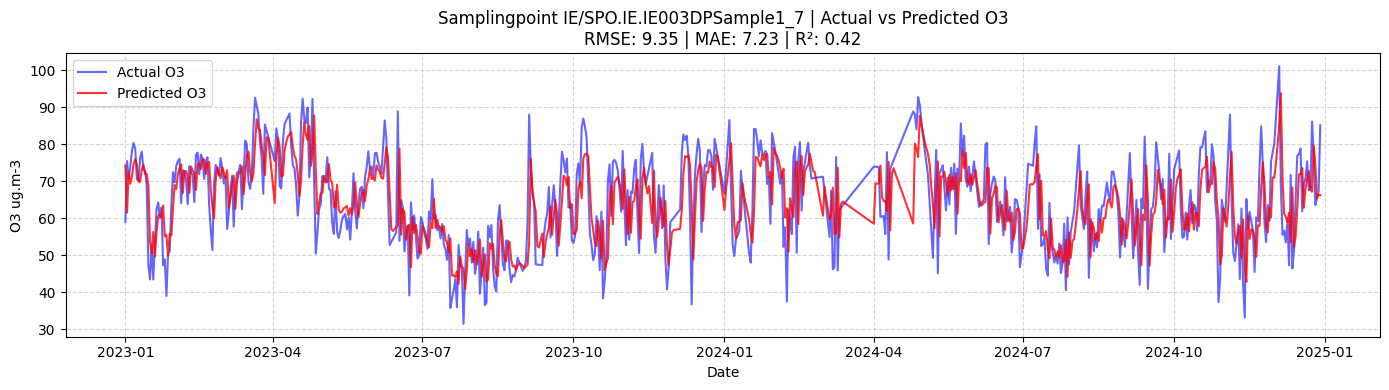

Station IE/SPO.IE.IE004BPSample2_7 -> RMSE: 9.65 | MAE: 7.73 | R2: 0.39


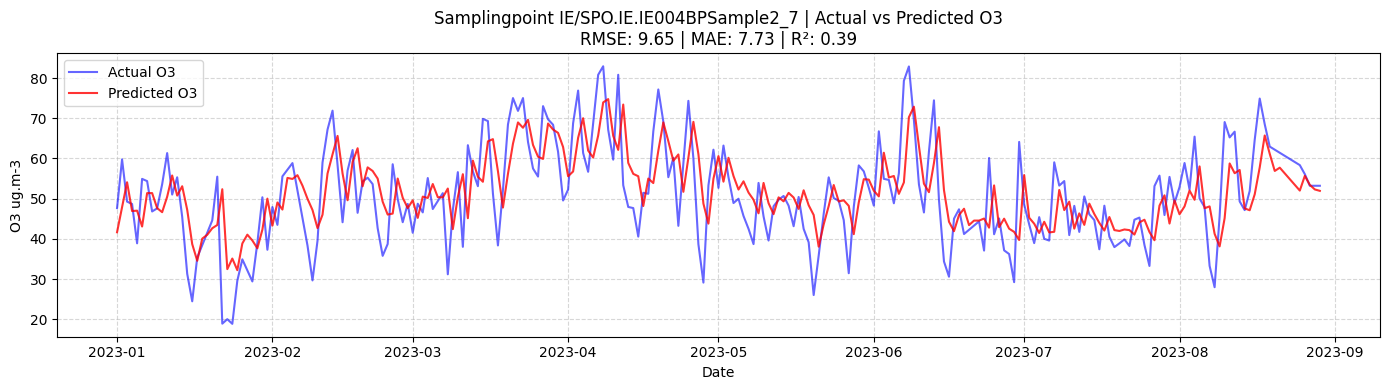

Station IE/SPO.IE.IE005CPSample2_7 -> RMSE: 10.85 | MAE: 8.32 | R2: 0.54


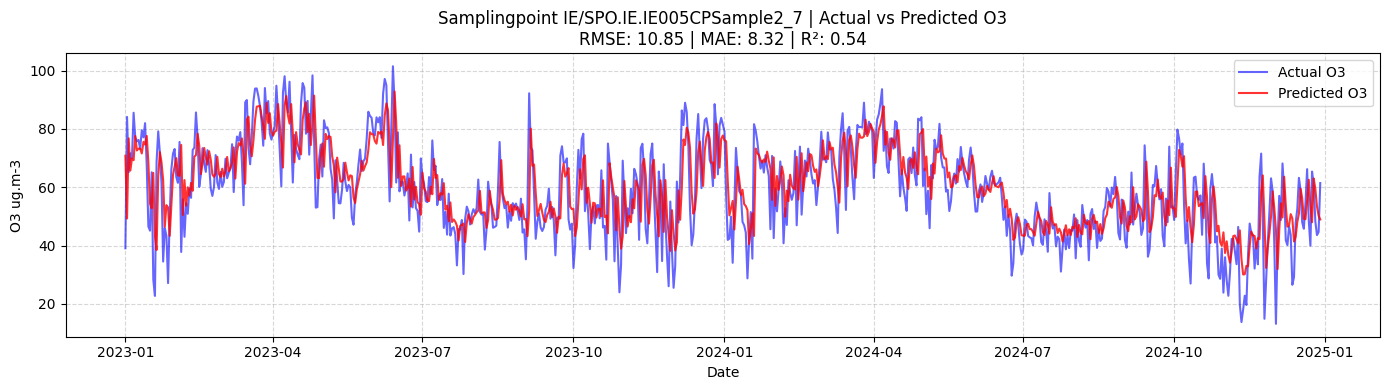

Station IE/SPO.IE.IE0147ASample1_7 -> RMSE: 11.16 | MAE: 8.47 | R2: 0.48


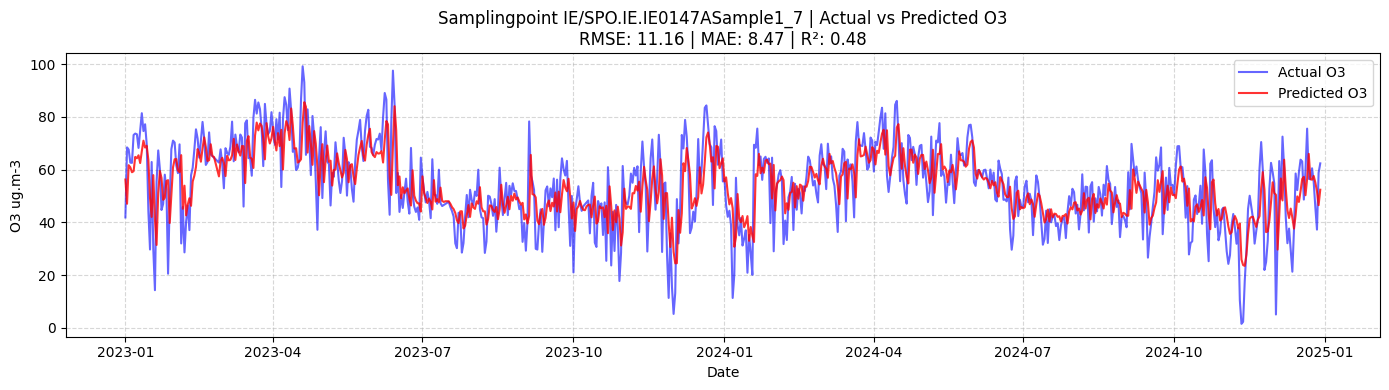

Station IE/SPO.IE.IE006APSample1_7 -> RMSE: 10.86 | MAE: 8.52 | R2: 0.40


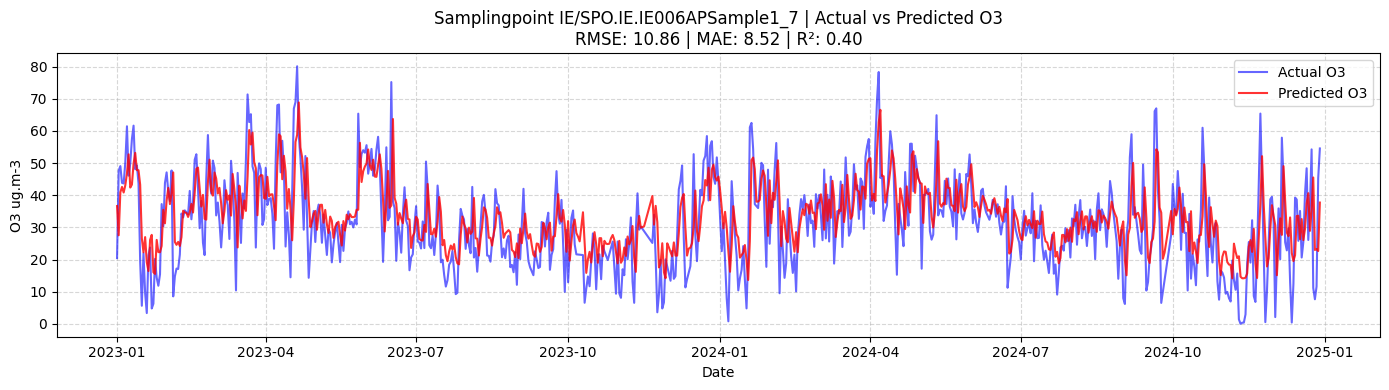

Station IE/SPO.IE.IE007CPSample2_7 -> RMSE: 11.43 | MAE: 8.85 | R2: 0.45


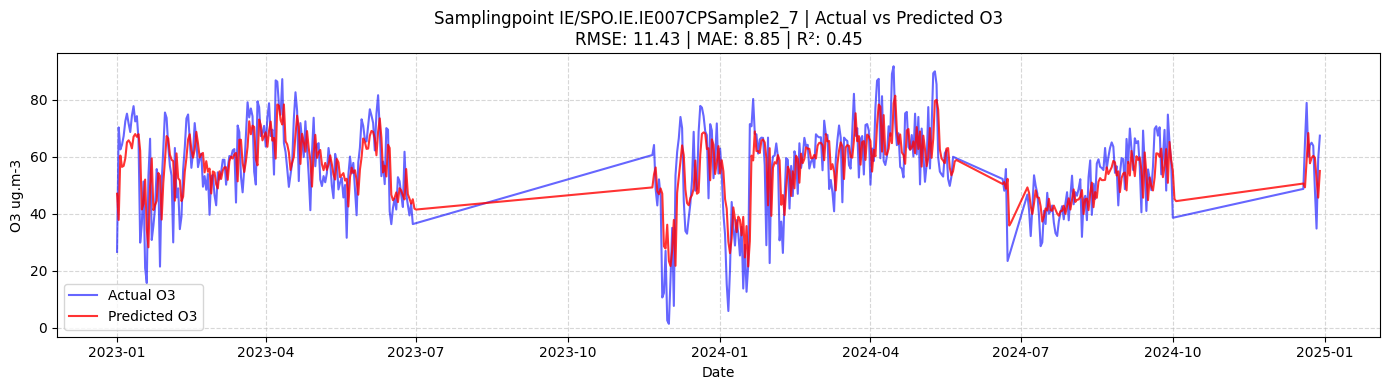

Station IE/SPO.IE.IE0090ASample1_7 -> RMSE: 8.18 | MAE: 6.20 | R2: 0.57


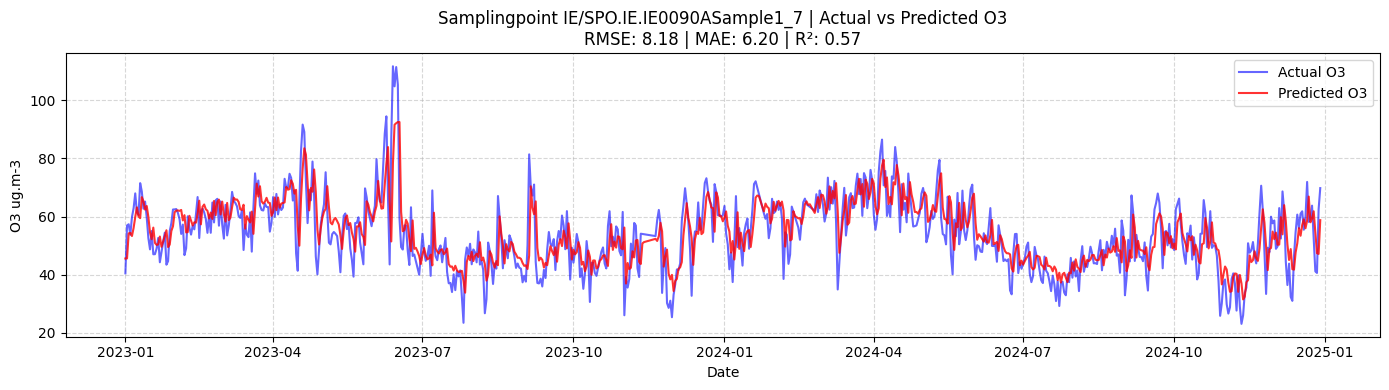

Station IE/SPO.IE.IE0141ASample1_7 -> RMSE: 10.91 | MAE: 8.52 | R2: 0.45


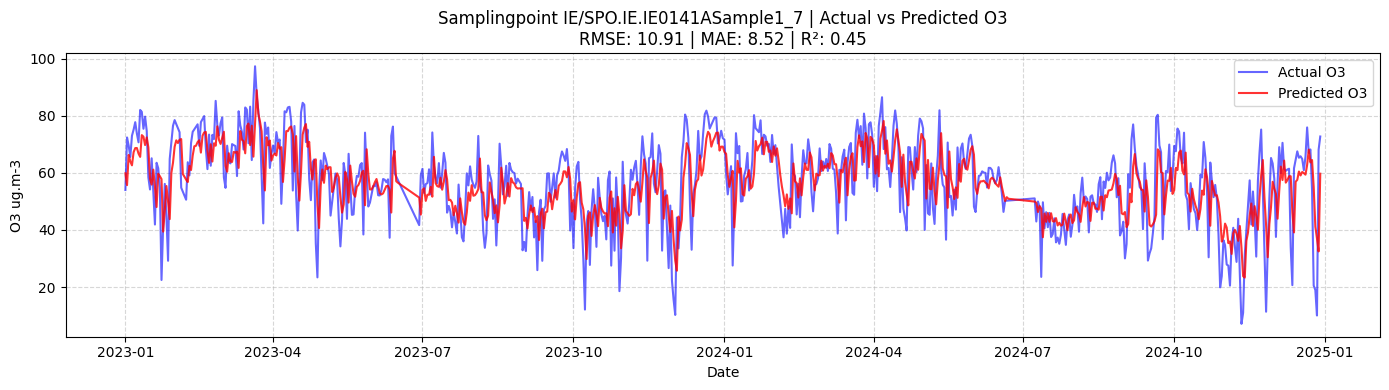

Station IE/SPO.IE.IE010LKSample2_7 -> RMSE: 10.61 | MAE: 8.11 | R2: 0.51


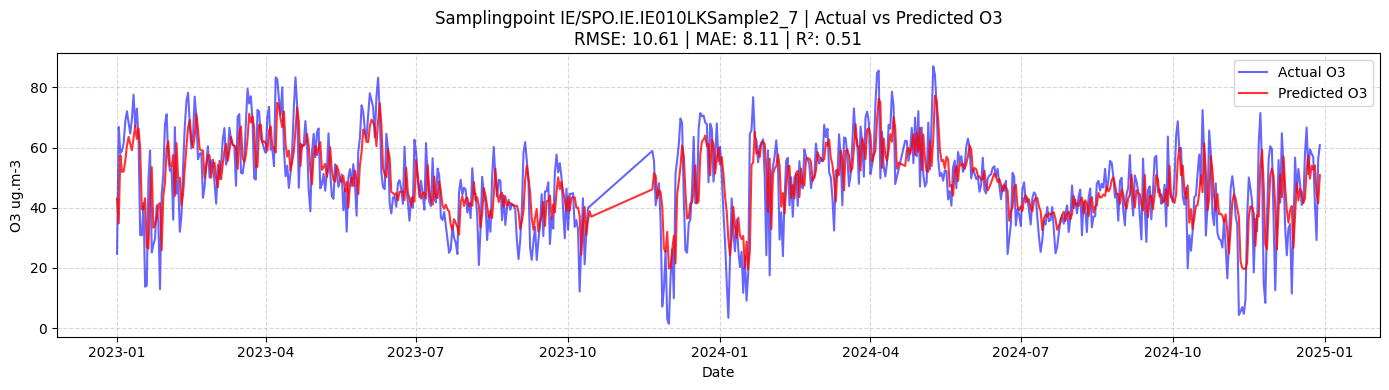

Station IE/SPO.IE.IE0111ASample1_7 -> RMSE: 8.77 | MAE: 6.83 | R2: 0.57


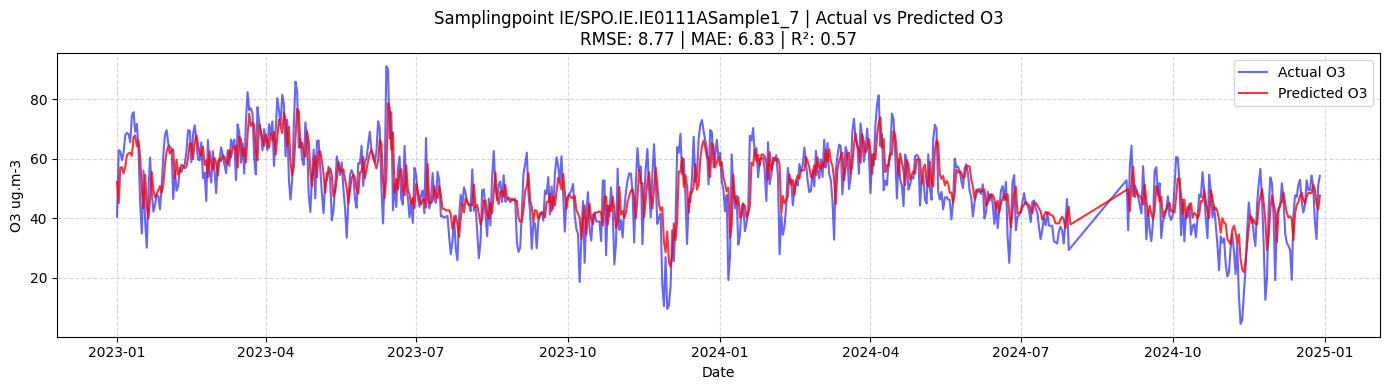

Station IE/SPO.IE.IE0118ASample1_7 -> RMSE: 11.01 | MAE: 8.59 | R2: 0.44


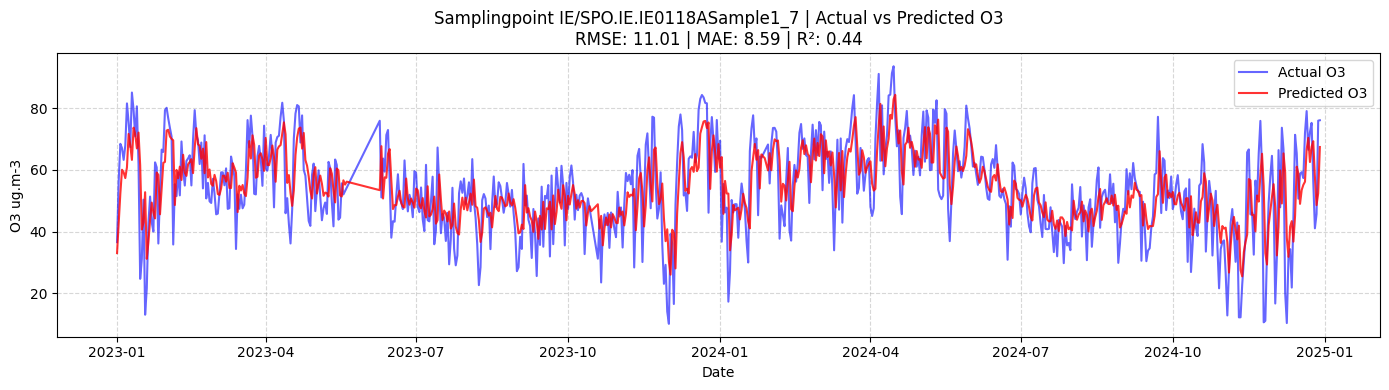

Station IE/SPO.IE.IE0140ASample1_7 -> RMSE: 10.52 | MAE: 8.08 | R2: 0.48


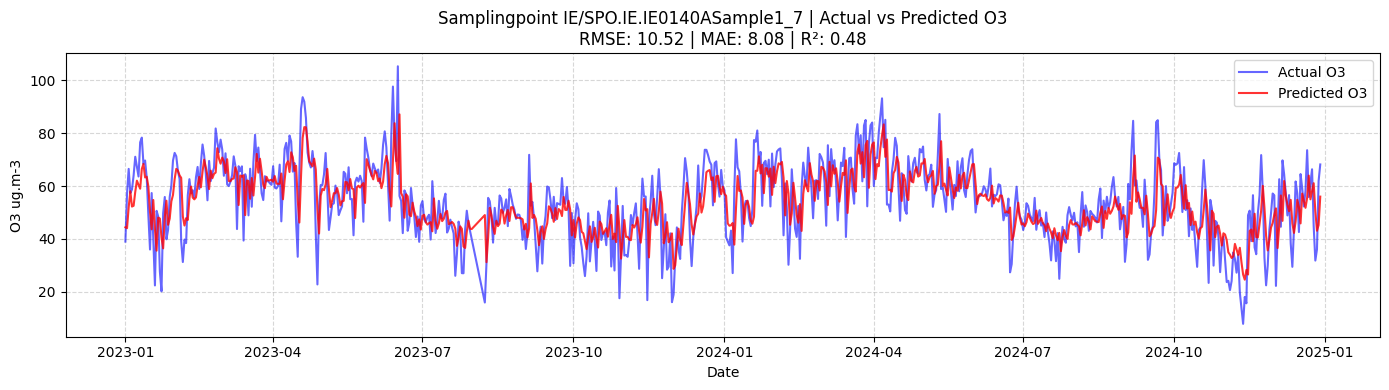

Station IE/SPO.IE.IE001DPSample1_7 -> RMSE: 8.38 | MAE: 6.48 | R2: 0.49


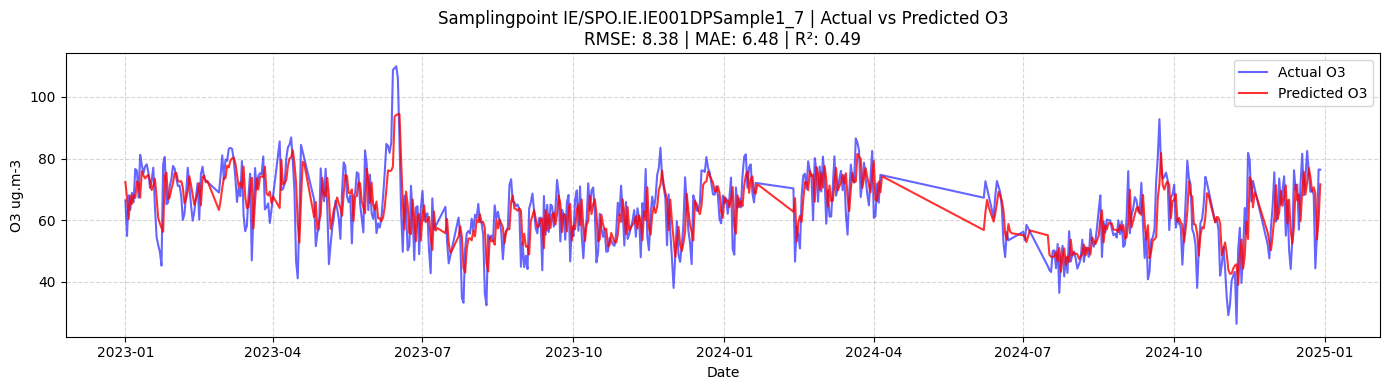

Station IE/SPO.IE.IE0127ASample1_7 -> RMSE: 11.08 | MAE: 8.59 | R2: 0.44


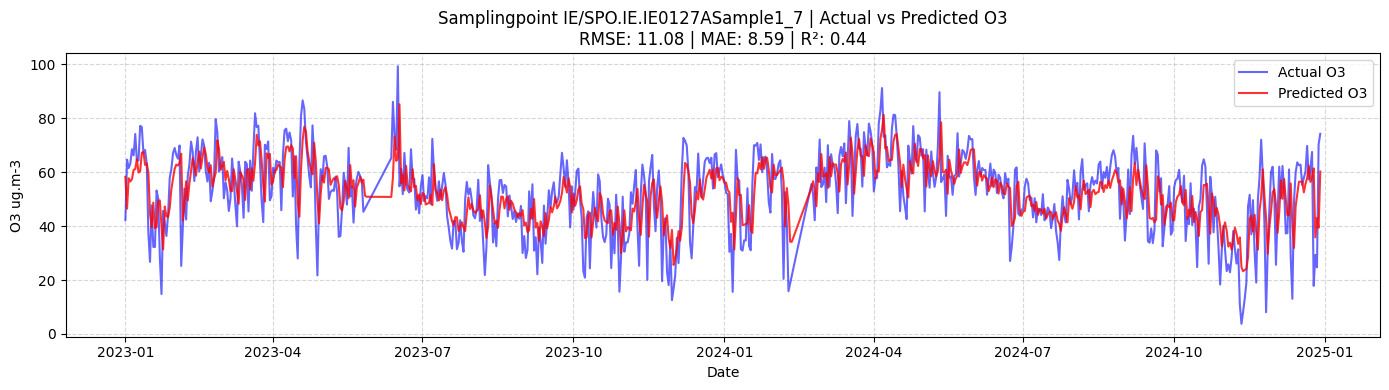

Station IE/SPO.IE.IE012CKSample2_7 -> RMSE: 12.30 | MAE: 9.58 | R2: 0.44


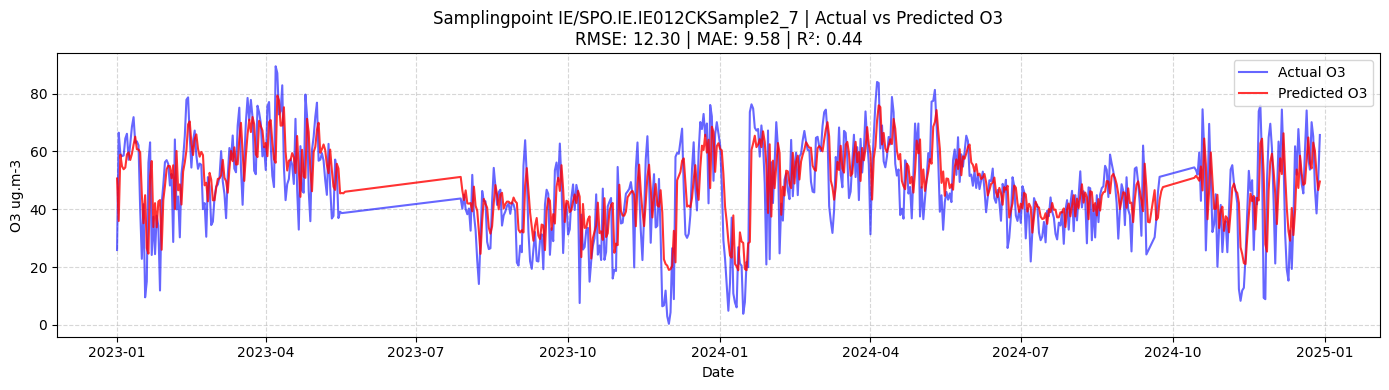

Station IE/SPO.IE.IE013CKSample2_7 -> RMSE: 12.16 | MAE: 9.64 | R2: 0.51


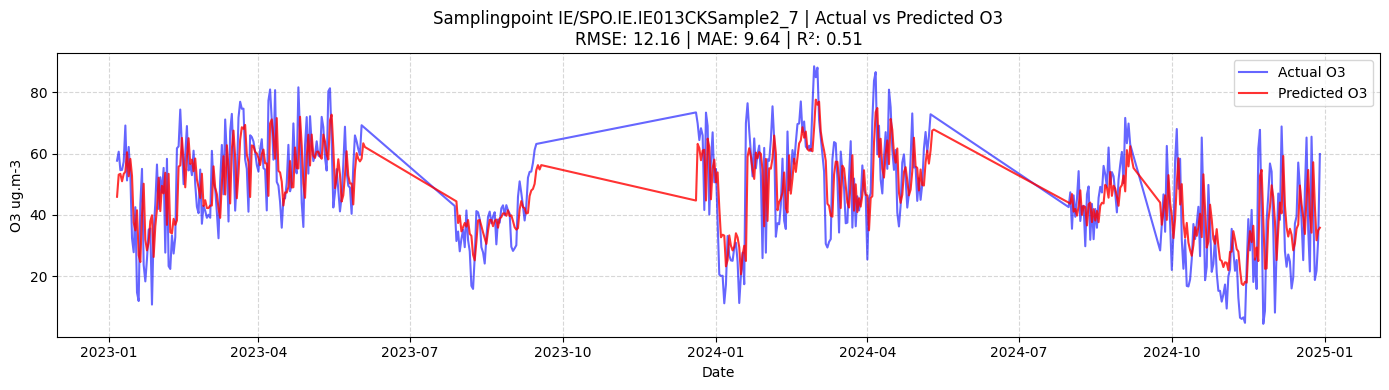

Station IE/SPO.IE.IE001WDSample1_7 -> RMSE: 11.07 | MAE: 8.58 | R2: 0.46


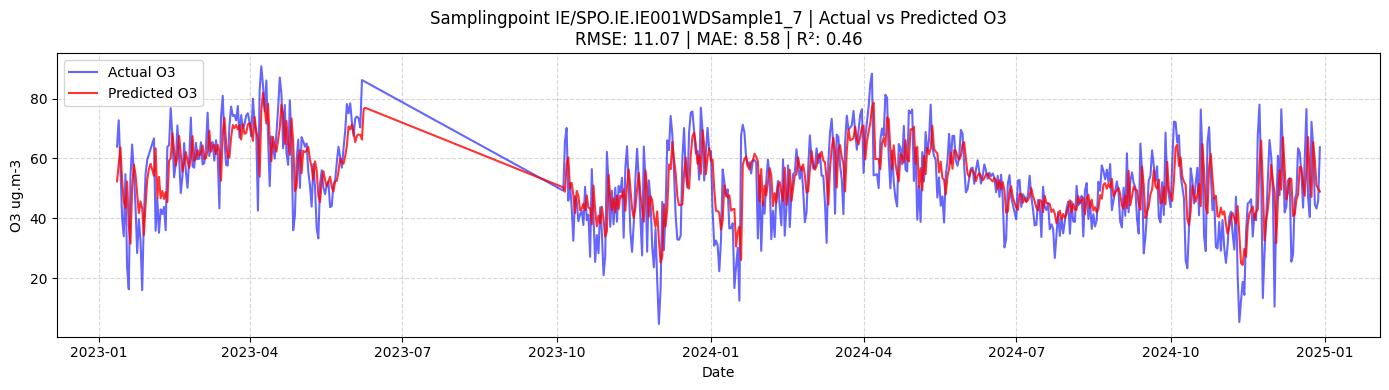

Station IE/SPO.IE.IE001BPSample1_7 -> RMSE: 9.37 | MAE: 7.14 | R2: 0.52


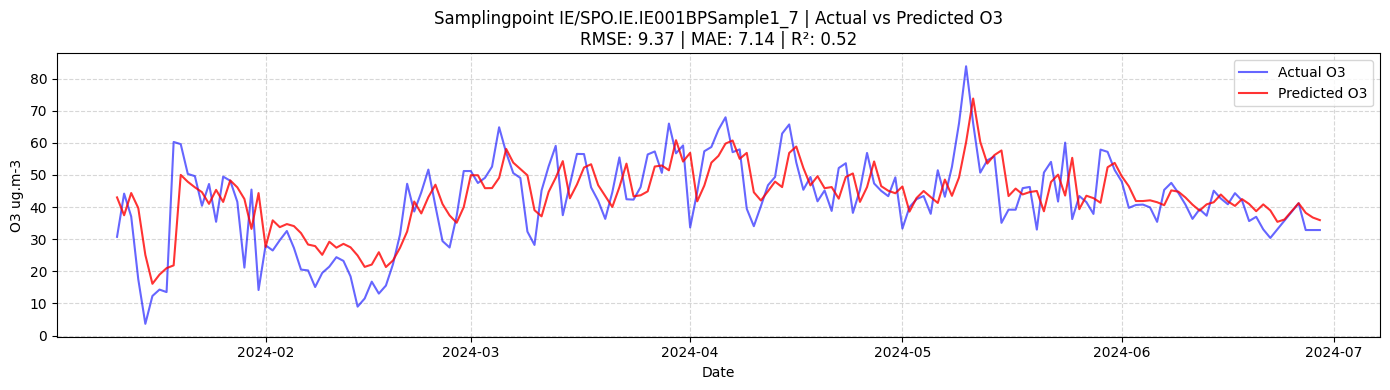

In [24]:
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

# Plotting Actual vs Predicted for each station in the Test Set
results_df = test_data.copy() # already grouped staion and start (date)
results_df['Actual'] = y_test
results_df['Predicted'] = test_preds


stations = results_df['Samplingpoint'].unique() 

for station in stations:
    station_data = results_df[results_df['Samplingpoint'] == station] 
    
    # Safety catch: skip stations with not enough data to calculate R2 for the stations that have shut down/little test data
    if len(station_data) < 2:
        continue
        
    st_rmse = np.sqrt(mean_squared_error(station_data['Actual'], station_data['Predicted']))
    st_mae = mean_absolute_error(station_data['Actual'], station_data['Predicted'])
    st_r2 = r2_score(station_data['Actual'], station_data['Predicted'])
    
    print(f"Station {station} -> RMSE: {st_rmse:.2f} | MAE: {st_mae:.2f} | R2: {st_r2:.2f}")
    

    plt.figure(figsize=(14, 4))
    
    # Using 'Start' for the x-axis datetime timeline
    plt.plot(station_data['Start'], station_data['Actual'], label='Actual O3', color='blue', alpha=0.6)
    plt.plot(station_data['Start'], station_data['Predicted'], label='Predicted O3', color='red', alpha=0.8, linewidth=1.5)
    
    plt.title(f'Samplingpoint {station} | Actual vs Predicted O3\nRMSE: {st_rmse:.2f} | MAE: {st_mae:.2f} | R²: {st_r2:.2f}')
    plt.xlabel('Date')
    plt.ylabel('O3 ug.m-3')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()